# LRTP Protocol Performance Analysis

This notebook analyzes the operation and performance of the Lightweight Reliable Transport Protocol (LRTP) implementation through comprehensive testing and visualization.

**Objective**: Understand protocol behavior, reliability, and performance through empirical test data analysis.

## Contents
1. Load and Parse Test Logs
2. Data Exploration and Summary Statistics
3. Test Success Rate Analysis
4. Performance Metrics Visualization
5. Protocol Behavior Analysis
6. Comparative Performance Analysis
7. Interpretation and Insights

In [90]:
import subprocess
import sys
import warnings
warnings.filterwarnings("ignore")

# Install required packages if not already installed
packages = ['pandas', 'numpy', 'matplotlib']
for package in packages:
    try:
        __import__(package)
        print(f"{package} is already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"{package} installed successfully")

pandas is already installed
numpy is already installed
matplotlib is already installed


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from datetime import datetime
import logging
from pathlib import Path


# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

logging.basicConfig(level=logging.ERROR)

log_dir = Path('./exemplar_logs')
plots_dir = Path('./plots')

# Create plots directory if missing
plots_dir.mkdir(parents=True, exist_ok=True)

if not log_dir.exists():
    logging.error(f"Log directory not found: {log_dir}")
else:
    files = list(log_dir.glob('*'))
    if not files:
        logging.error(f"Log directory is empty: {log_dir}")

In [92]:
# Parse test summary and categorize tests
summary_file = log_dir / 'test_summary.txt'

def parse_test_summary(summary_path):
    """Parse the test summary file and extract test metrics"""
    tests = []
    
    if not summary_path.exists():
        print(f"Warning: {summary_path} not found")
        return pd.DataFrame(), {}
    
    with open(summary_path, 'r') as f:
        content = f.read()
    
    # Extract metadata
    start_time_match = re.search(r'Start Time: (.*)', content)
    end_time_match = re.search(r'End Time: (.*)', content)
    client_host_match = re.search(r'Client Host: (.*)', content)
    server_host_match = re.search(r'Server Host: (.*)', content)
    
    # Extract test results
    test_pattern = r'Test (\d+): ([\w-]+) - (PASSED|FAILED) \((\d+)s\)'
    matches = re.findall(test_pattern, content)
    
    for test_num, test_name, status, duration in matches:
        tests.append({
            'Test_Num': int(test_num),
            'Test_Name': test_name,
            'Status': status,
            'Duration_s': int(duration),
            'Passed': status == 'PASSED'
        })
    
    return pd.DataFrame(tests), {
        'Start_Time': start_time_match.group(1) if start_time_match else 'Unknown',
        'End_Time': end_time_match.group(1) if end_time_match else 'Unknown',
        'Client_Host': client_host_match.group(1) if client_host_match else 'Unknown',
        'Server_Host': server_host_match.group(1) if server_host_match else 'Unknown'
    }

def categorize_tests(df):
    """Categorize tests based on their names"""
    def get_category(name):
        if 'adaptive' in name.lower():
            return 'Adaptive RTO'
        elif 'large' in name.lower():
            return 'Large Transfer'
        elif 'multiple' in name.lower() or 'sends' in name.lower():
            return 'Multiple Sends'
        elif 'stress' in name.lower():
            return 'Stress Test'
        else:
            return 'Basic Connectivity'
    
    df['Category'] = df['Test_Name'].apply(get_category)
    return df

# Load the data
df_tests, metadata = parse_test_summary(summary_file)
df_tests = categorize_tests(df_tests)

# Extract hostname info for use in visualizations
server_host = metadata.get('Server_Host', 'unknown')
client_host = metadata.get('Client_Host', 'unknown')

print("\n" + "="*60)
print(f"LRTP PROTOCOL TEST RESULTS")
print(f"Server: {server_host}, Client: {client_host}")
print("="*60)
print(f"Total Tests: {len(df_tests)} | Passed: {df_tests['Passed'].sum()} | Failed: {(~df_tests['Passed']).sum()}")
print(f"Success Rate: {100*df_tests['Passed'].sum()/len(df_tests):.1f}%")


LRTP PROTOCOL TEST RESULTS
Server: pc1-036-l, Client: pc2-002-l
Total Tests: 8 | Passed: 8 | Failed: 0
Success Rate: 100.0%


## Section 1: Data Summary

Quick overview of test results and execution metrics.

In [93]:
print("\n" + "="*70)
print("TEST SUMMARY STATISTICS")
print("="*70)

# Summary statistics
success_rate = 100*df_tests['Passed'].sum()/len(df_tests)
passed_tests = df_tests['Passed'].sum()
failed_tests = (~df_tests['Passed']).sum()
total_tests = len(df_tests)

print(f"Total Tests: {total_tests}")
print(f"Passed: {passed_tests} | Failed: {failed_tests}")
print(f"Success Rate: {success_rate:.1f}%")
print(f"\nExecution Time Stats:")
print(f"  Min: {df_tests['Duration_s'].min()}s")
print(f"  Max: {df_tests['Duration_s'].max()}s")
print(f"  Mean: {df_tests['Duration_s'].mean():.2f}s")
print(f"  Std Dev: {df_tests['Duration_s'].std():.2f}s")


TEST SUMMARY STATISTICS
Total Tests: 8
Passed: 8 | Failed: 0
Success Rate: 100.0%

Execution Time Stats:
  Min: 3s
  Max: 65s
  Mean: 25.88s
  Std Dev: 30.76s


## Section 2: Performance Visualization

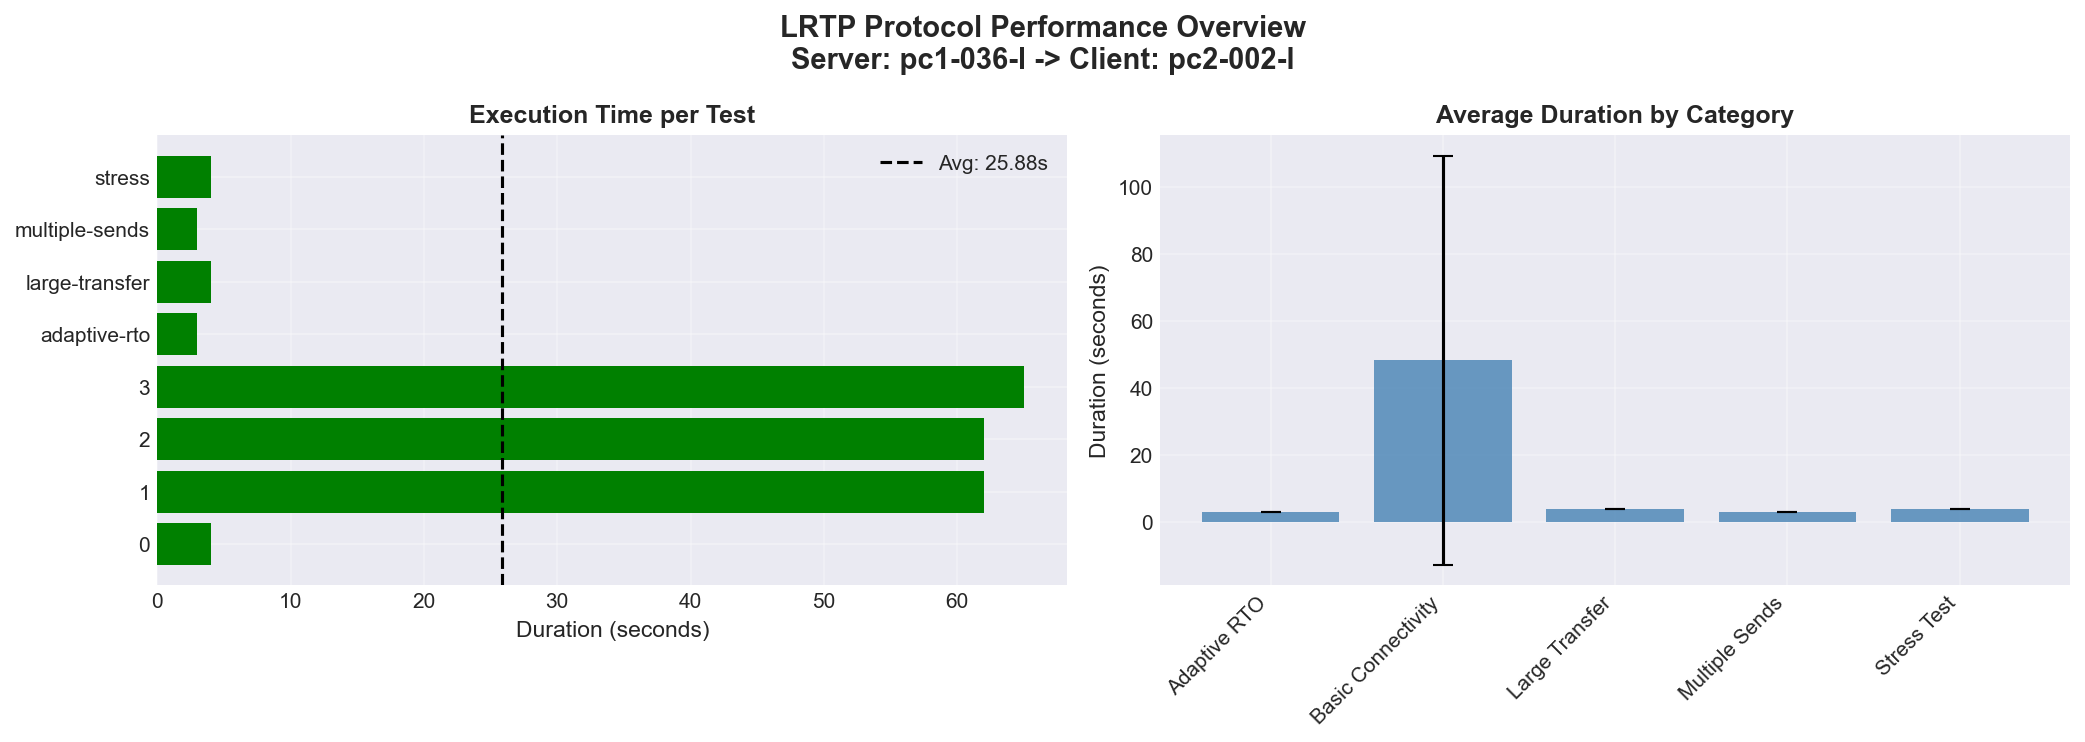

Performance Overview Complete


In [94]:
server_host = metadata.get('Server_Host', 'unknown')
client_host = metadata.get('Client_Host', 'unknown')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    f'LRTP Protocol Performance Overview\nServer: {server_host} -> Client: {client_host}',
    fontsize=14,
    fontweight='bold'
)

# 1. Execution time by test
ax1 = axes[0]

colors = ['green' if passed else 'red' for passed in df_tests['Passed']]

ax1.barh(
    df_tests['Test_Name'].astype(str),
    df_tests['Duration_s'],
    color=colors
)

ax1.axvline(
    df_tests['Duration_s'].mean(),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f"Avg: {df_tests['Duration_s'].mean():.2f}s"
)

ax1.set_xlabel('Duration (seconds)')
ax1.set_title('Execution Time per Test', fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. Category comparison
ax2 = axes[1]

cat_dur = df_tests.groupby('Category')['Duration_s'].agg(['mean', 'min', 'max'])

ax2.bar(
    range(len(cat_dur)),
    cat_dur['mean'],
    yerr=cat_dur['max'] - cat_dur['min'],
    capsize=5,
    color='steelblue',
    alpha=0.8
)

ax2.set_xticks(range(len(cat_dur)))
ax2.set_xticklabels(cat_dur.index, rotation=45, ha='right')
ax2.set_ylabel('Duration (seconds)')
ax2.set_title('Average Duration by Category', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/fig1_performance_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("Performance Overview Complete")

## Section 3: Adaptive vs Fixed RTO Analysis

Compare adaptive RTO performance against fixed RTO implementation.


ADAPTIVE vs FIXED RTO COMPARISON
Network: Server pc1-036-l ↔ Client pc2-002-l

Test Result: PASSED (3s)

RTO Data Found: 10 packets traced
  Initial RTO: 1.000000s
  Final RTO: 1.000000s
  Min RTO: 1.000000s
  Max RTO: 1.000000s
  Median RTO: 1.000000s


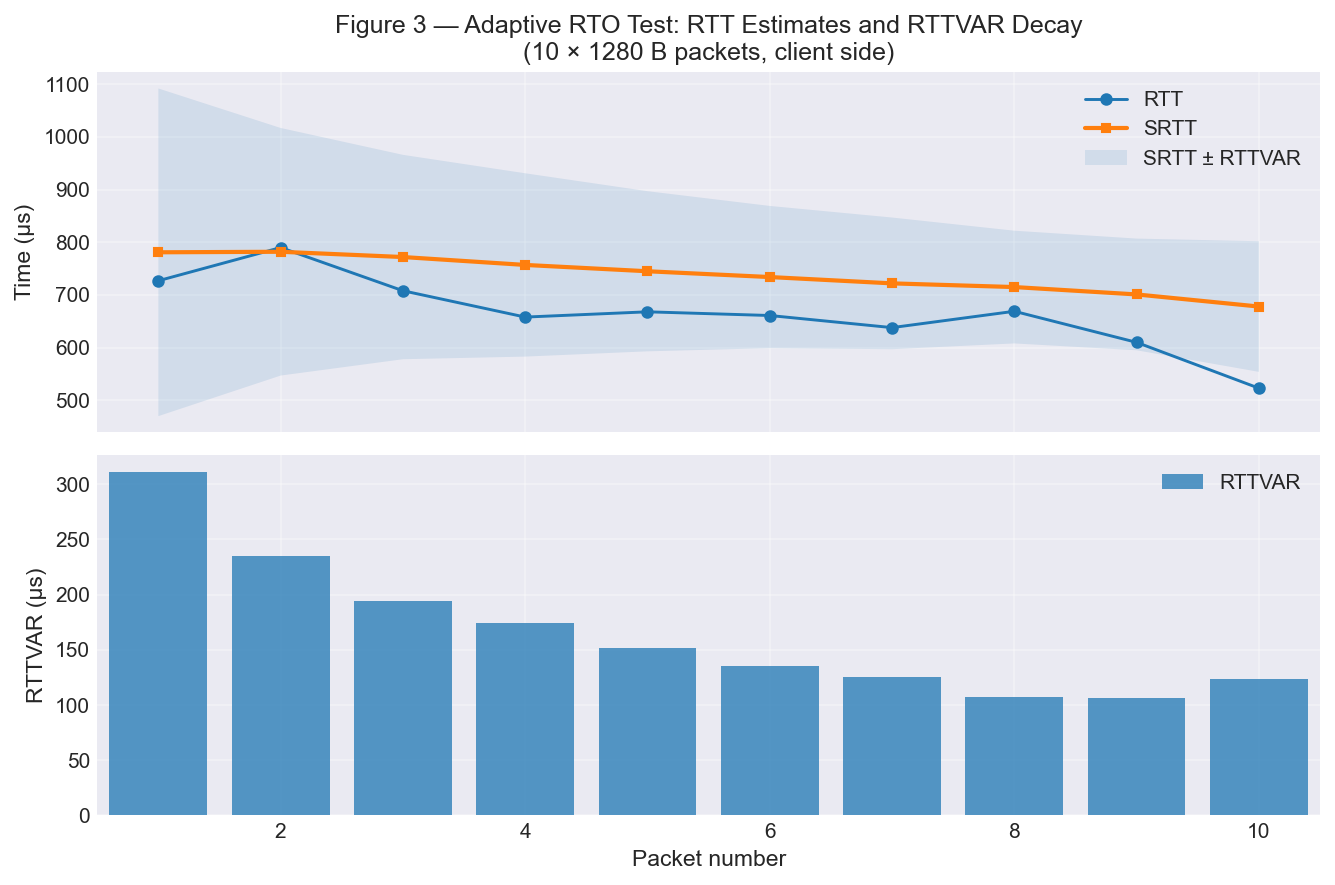

In [95]:
# Adaptive vs Fixed RTO Analysis
rto_test = df_tests[df_tests['Test_Name'] == 'adaptive-rto']

if not rto_test.empty:
    print("\n" + "="*60)
    print("ADAPTIVE vs FIXED RTO COMPARISON")
    print(f"Network: Server {server_host} ↔ Client {client_host}")
    print("="*60)

    log_file = Path(log_dir) / 'adaptive-rto_client.log'

    df_rto = None
    adaptive_status = "PASSED" if rto_test['Passed'].values[0] else "FAILED"
    adaptive_duration = rto_test['Duration_s'].values[0]

    print(f"\nTest Result: {adaptive_status} ({adaptive_duration}s)")

    # Parse log file for RTO data
    if log_file.exists():
        with open(log_file, 'r') as f:
            lines = f.readlines()

        rto_rows = []
        in_table = False

        for line in lines:
            line = line.strip()

            # Start of table
            if line.startswith('Packet'):
                in_table = True
                continue

            # Skip separator
            if in_table and line.startswith('--------'):
                continue

            # End of table
            if in_table and line == '':
                break

            # Parse rows
            if in_table and '|' in line:
                parts = [p.strip() for p in line.split('|')]

                if len(parts) >= 6:
                    try:
                        rto_rows.append({
                            'Packet': int(parts[0]),
                            'RTT_us': int(parts[1]),
                            'SRTT_us': int(parts[2]),
                            'RTTVAR_us': int(parts[3]),
                            'RTO_us': int(parts[4]),
                            'RTO_s': int(parts[4]) / 1_000_000
                        })
                    except ValueError:
                        continue

        if rto_rows:
            df_rto = pd.DataFrame(rto_rows)

            print(f"\nRTO Data Found: {len(df_rto)} packets traced")
            print(f"  Initial RTO: {df_rto['RTO_s'].iloc[0]:.6f}s")
            print(f"  Final RTO: {df_rto['RTO_s'].iloc[-1]:.6f}s")
            print(f"  Min RTO: {df_rto['RTO_s'].min():.6f}s")
            print(f"  Max RTO: {df_rto['RTO_s'].max():.6f}s")
            print(f"  Median RTO: {df_rto['RTO_s'].median():.6f}s")

    else:
        print(f"\nLog file not found: {log_file}")

    if df_rto is None:
        print("\nRTO parsing failed")
    
    # Plot results
    else:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

        # Top plot: RTT + SRTT + RTTVAR band
        ax1.plot(df_rto['Packet'], df_rto['RTT_us'],
                 marker='o', ms=5, lw=1.4, label='RTT')

        ax1.plot(df_rto['Packet'], df_rto['SRTT_us'],
                 marker='s', ms=4, lw=2, label='SRTT')

        lower = df_rto['SRTT_us'] - df_rto['RTTVAR_us']
        upper = df_rto['SRTT_us'] + df_rto['RTTVAR_us']

        ax1.fill_between(df_rto['Packet'], lower, upper,
                         alpha=0.12, label='SRTT ± RTTVAR')

        ax1.set_ylabel('Time (μs)')
        ax1.set_title(
            'Figure 3 — Adaptive RTO Test: RTT Estimates and RTTVAR Decay\n'
            '(10 × 1280 B packets, client side)'
        )
        ax1.legend(loc='upper right')

        # Bottom plot: RTTVAR
        ax2.bar(df_rto['Packet'], df_rto['RTTVAR_us'],
                alpha=0.75, label='RTTVAR')

        ax2.set_xlabel('Packet number')
        ax2.set_ylabel('RTTVAR (μs)')
        ax2.set_xlim(0.5, len(df_rto) + 0.5)
        ax2.legend()

        plt.tight_layout()
        plt.savefig('plots/fig2_adaptive_rto_estimates')

## Section 4: Dynamic RTT across multi-packet tests (3 tests)


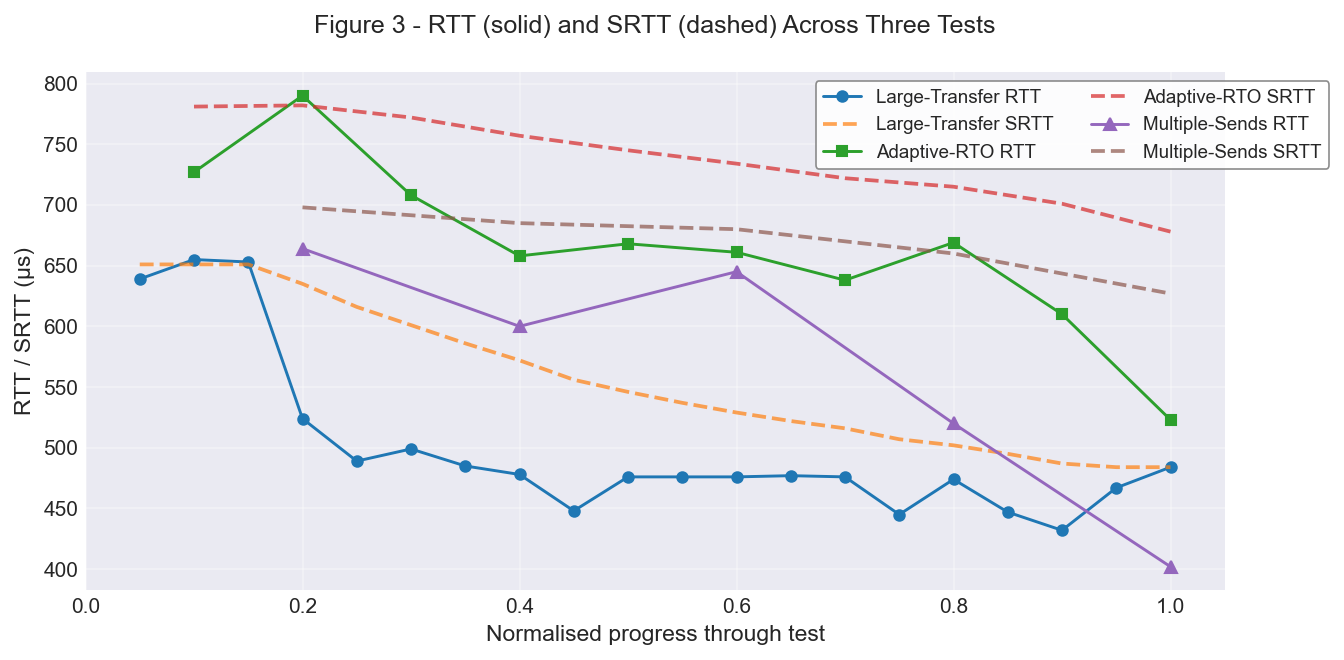

In [96]:
# Parse RTT tables from all three multi-packet tests for comparison
def parse_rtt_table(log_path):
    if not log_path.exists():
        print(f"Missing log: {log_path}")
        return None

    with open(log_path, 'r') as f:
        lines = f.readlines()

    rows = []
    in_table = False

    for raw_line in lines:
        line = raw_line.strip()
        if ('Packet' in line and 'RTT' in line) or ('Payload' in line and 'RTT' in line):
            in_table = True
            continue

        # skip separator row
        if in_table and '-' in line:
            continue

        # end of table
        if in_table and line == '':
            break

        # parse rows
        if in_table and '|' in line:
            parts = [p.strip() for p in line.split('|')]

            # remove empty columns if any
            parts = [p for p in parts if p]

            if len(parts) >= 5:
                try:
                    rows.append({
                        'pkt': int(parts[0]),
                        'rtt': int(parts[1]),
                        'srtt': int(parts[2]),
                        'rttvar': int(parts[3]),
                    })
                except ValueError:
                    continue

    if not rows:
        print(f"No data parsed from: {log_path}")
        return None

    df = pd.DataFrame(rows)

    return {
        'pkt': df['pkt'].tolist(),
        'rtt': df['rtt'].tolist(),
        'srtt': df['srtt'].tolist(),
        'rttvar': df['rttvar'].tolist(),
    }

#Load datasets from logs
large_transfer_client = parse_rtt_table(log_dir / 'large-transfer_client.log')
adaptive_rto_client   = parse_rtt_table(log_dir / 'adaptive-rto_client.log')
multiple_sends_client = parse_rtt_table(log_dir / 'multiple-sends_client.log')

# Plot
fig, ax = plt.subplots(figsize=(9, 4.5))

def normalise(pkt):
    return np.array(pkt) / max(pkt)

# Large Transfer
if large_transfer_client:
    lt = large_transfer_client
    x = normalise(lt['pkt'])
    ax.plot(x, lt['rtt'],
            marker='o', ms=5, lw=1.4, label='Large-Transfer RTT')
    ax.plot(x, lt['srtt'],
            lw=1.8, ls='--', alpha=0.7, label='Large-Transfer SRTT')

# Adaptive RTO
if adaptive_rto_client:
    ar = adaptive_rto_client
    x = normalise(ar['pkt'])
    ax.plot(x, ar['rtt'],
            marker='s', ms=5, lw=1.4, label='Adaptive-RTO RTT')
    ax.plot(x, ar['srtt'],
            lw=1.8, ls='--', alpha=0.7, label='Adaptive-RTO SRTT')

# Multiple Sends
if multiple_sends_client:
    ms = multiple_sends_client
    x = normalise(ms['pkt'])
    ax.plot(x, ms['rtt'],
            marker='^', ms=6, lw=1.4, label='Multiple-Sends RTT')
    ax.plot(x, ms['srtt'],
            lw=1.8, ls='--', alpha=0.7, label='Multiple-Sends SRTT')


# Format the plot
ax.set_xlabel('Normalised progress through test')
ax.set_ylabel('RTT / SRTT (μs)')

ax.set_title(
    'Figure 3 - RTT (solid) and SRTT (dashed) Across Three Tests\n'
)

ax.set_xlim(0, 1.05)
legend = ax.legend(
    ncol=2,
    fontsize=9,              
    frameon=True,
    fancybox=True,      
    framealpha=0.9,
    loc='upper right',
    bbox_to_anchor=(1.1, 1)
)

# style the legend box
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('grey') 
legend.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.savefig('plots/fig3_rtt_all_tests_normalised')

## Section 6: RTT Stress Test

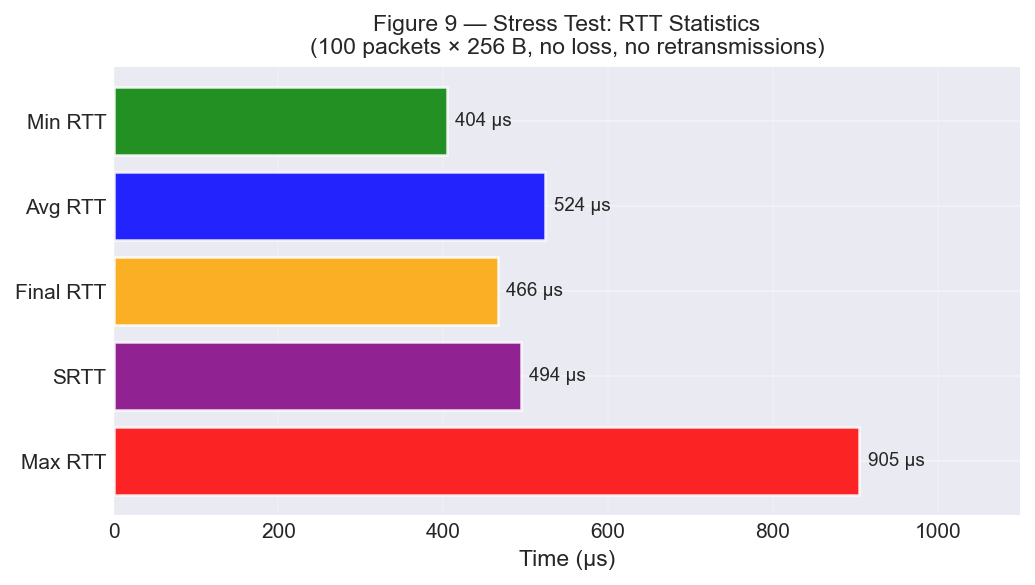

In [97]:
# Parse stress test log for RTT stats
def parse_stress_log(log_path):
    if not log_path.exists():
        print(f"Missing log: {log_path}")
        return None

    with open(log_path, 'r') as f:
        text = f.read()

    def find(pattern):
        m = re.search(pattern, text)
        return float(m.group(1)) if m else None

    data = {
        'min_rtt_us': find(r"Min RTT:\s*([0-9.]+)"),
        'avg_rtt_us': find(r"Avg RTT:\s*([0-9.]+)"),
        'max_rtt_us': find(r"Max RTT:\s*([0-9.]+)"),
        'srtt_us': find(r"Smoothed RTT:\s*([0-9.]+)"),
    }

    # fallback for final RTT (last observed RTT line)
    last_rtt = re.findall(r"rtt:\s*([0-9.]+)\s*us", text)
    data['rtt_us'] = float(last_rtt[-1]) if last_rtt else data['avg_rtt_us']

    if any(v is None for v in data.values()):
        print("Stress log parsing incomplete")
        return None

    return data

# Load stress test RTT stats
stress_data = parse_stress_log(log_dir / 'stress_client.log')

if stress_data is None:
    raise ValueError("Stress log parsing failed — check log format")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

categories = ['Min RTT', 'Avg RTT', 'Final RTT', 'SRTT', 'Max RTT']

values = [
    stress_data['min_rtt_us'],
    stress_data['avg_rtt_us'],
    stress_data['rtt_us'],
    stress_data['srtt_us'],
    stress_data['max_rtt_us']
]

colours = ['green', 'blue', 'orange', 'purple', 'red']

bars = ax.barh(
    categories,
    values,
    color=colours,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2,
    zorder=3
)

# Value labels
for bar, v in zip(bars, values):
    ax.text(
        v + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{v:.0f} μs',
        va='center',
        fontsize=9
    )

# Format the plot
ax.set_xlabel('Time (μs)')
ax.set_title(
    'Figure 9 — Stress Test: RTT Statistics\n'
    '(100 packets × 256 B, no loss, no retransmissions)',
    fontsize=11
)

ax.set_xlim(0, 1100)
ax.invert_yaxis()

ax.grid(axis='x', alpha=0.2, zorder=0)

for spine in ax.spines.values():
    spine.set_alpha(0.3)

plt.tight_layout()
plt.savefig('plots/fig4_stress_rtt_stats')

## Section 7: Summary

In [98]:
import glob
import os
print('Generated files:')
for f in sorted(glob.glob('plots/*')):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<50} {size_kb:6.1f} KB')

Generated files:
  plots/fig1_performance_overview.png                 213.5 KB
  plots/fig2_adaptive_rto_estimates.png               170.5 KB
  plots/fig3_rtt_all_tests_normalised.png             262.6 KB
  plots/fig4_stress_rtt_stats.png                      82.7 KB
